# **KYC Funnel Drop-off Analysis**

This notebook analyzes where users abandon the KYC flow using the uploaded fintech datasets.

## **Business question**
Where exactly do users drop out of KYC, and which segments show the most friction?

## **Files used**
- `fintech_users.csv`
- `fintech_devices.csv`
- `network_logs.csv`
- `sessions.csv`
- `kyc_events.csv`


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

users_path    = "fintech_users.csv"
devices_path  = "fintech_devices.csv"
network_path  = "network_logs.csv"
sessions_path = "sessions.csv"
kyc_path      = "kyc_events.csv"

# Load all source tables
users    = pd.read_csv(users_path)
devices  = pd.read_csv(devices_path)
network  = pd.read_csv(network_path)
sessions = pd.read_csv(sessions_path)
kyc      = pd.read_csv(kyc_path)

# Parse datetime columns so time-based analysis works correctly
users["signup_time"] = pd.to_datetime(users["signup_time"], errors="coerce")
sessions["session_start"] = pd.to_datetime(sessions["session_start"], errors="coerce")

print("users:", users.shape)
print("devices:", devices.shape)
print("network:", network.shape)
print("sessions:", sessions.shape)
print("kyc_events:", kyc.shape)


users: (100000, 6)
devices: (100000, 5)
network: (100000, 5)
sessions: (149851, 4)
kyc_events: (720012, 8)


## **Join all KYC events to user, device, session, and network context**

In [4]:
# Derive day_of_week from the session timestamp
sessions["day_of_week"] = sessions["session_start"].dt.day_name()

# Build one enriched event-level table for most downstream analysis
kyc_enriched = (
    kyc.merge(
        sessions[["session_id", "user_id", "session_start", "time_of_day", "day_of_week"]],
        on=["session_id", "user_id"],
        how="left"
    )
    .merge(users, on="user_id", how="left")
    .merge(devices, on="user_id", how="left")
    .merge(network, on="user_id", how="left")
)

kyc_enriched.head()


,event_id,user_id,session_id,kyc_step,status,duration_seconds,retry_count,error_code,session_start,time_of_day,...,acquisition_source,fraud_risk_score,device_type,os,device_model,camera_quality_score,network_type,latency_ms,packet_loss,upload_speed_mbps
0,1,U0000000,S1,start_kyc,success,32,1,NaN,2026-01-13 15:29:26.098794,afternoon,...,google_ads,0.105444,mobile,Android,iPhone 13,6,wifi,117.311867,0.019534,12.981264
1,2,U0000000,S1,phone_verification,success,117,1,face_mismatch,2026-01-13 15:29:26.098794,afternoon,...,google_ads,0.105444,mobile,Android,iPhone 13,6,wifi,117.311867,0.019534,12.981264
2,3,U0000000,S1,personal_information,fail,49,0,blurry_document,2026-01-13 15:29:26.098794,afternoon,...,google_ads,0.105444,mobile,Android,iPhone 13,6,wifi,117.311867,0.019534,12.981264
3,4,U0000000,S1,document_upload,success,82,0,blurry_document,2026-01-13 15:29:26.098794,afternoon,...,google_ads,0.105444,mobile,Android,iPhone 13,6,wifi,117.311867,0.019534,12.981264
4,5,U0000000,S2,start_kyc,success,25,0,NaN,2026-02-13 06:04:40.690859,evening,...,google_ads,0.105444,mobile,Android,iPhone 13,6,wifi,117.311867,0.019534,12.981264


## **Data quality checks**

In [5]:
# Quick missingness + uniqueness review
dq = pd.DataFrame({
    "column": kyc_enriched.columns,
    "missing_pct": (kyc_enriched.isna().mean() * 100).round(2).values,
    "n_unique": [kyc_enriched[c].nunique(dropna=True) for c in kyc_enriched.columns],
    "dtype": [str(kyc_enriched[c].dtype) for c in kyc_enriched.columns]
})

dq.sort_values("missing_pct", ascending=False).head(15)


,column,missing_pct,n_unique,dtype
7,error_code,20.05,4,object
0,event_id,0.00,720012,int64
2,session_id,0.00,149851,object
1,user_id,0.00,100000,object
3,kyc_step,0.00,10,object
4,status,0.00,3,object
5,duration_seconds,0.00,115,int64
6,retry_count,0.00,3,int64
8,session_start,0.00,149851,datetime64[ns]
9,time_of_day,0.00,4,object


## **Define the canonical funnel order**

In [6]:
funnel_steps = [
    "start_kyc",
    "phone_verification",
    "personal_information",
    "document_upload",
    "document_validation",
    "selfie_capture",
    "face_match",
    "address_verification",
    "manual_review",
    "kyc_approved",
]

print(sorted(kyc_enriched["kyc_step"].unique()))


['address_verification', 'document_upload', 'document_validation', 'face_match', 'kyc_approved', 'manual_review', 'personal_information', 'phone_verification', 'selfie_capture', 'start_kyc']


## **Funnel: users reached and users succeeded at each step**

In [7]:
# A user 'reached' a step if they have at least one event at that step
step_reached = (
    kyc_enriched.groupby(["user_id", "kyc_step"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=funnel_steps)
    .fillna(0)
)
step_reached = (step_reached > 0).astype(int)

# A user 'succeeded' a step if they recorded status == success at least once at that step
step_success = (
    kyc_enriched.assign(success=(kyc_enriched["status"] == "success").astype(int))
    .groupby(["user_id", "kyc_step"])["success"]
    .max()
    .unstack(fill_value=0)
    .reindex(columns=funnel_steps)
    .fillna(0)
    .astype(int)
)

funnel = pd.DataFrame({
    "step": funnel_steps,
    "users_reached": [int(step_reached[s].sum()) for s in funnel_steps],
    "users_succeeded": [int(step_success[s].sum()) for s in funnel_steps],
})

# Reach rate vs start step
funnel["reach_rate_vs_start"] = funnel["users_reached"] / funnel.loc[0, "users_reached"]

# Step conversion conditional on reaching the step
funnel["success_rate_at_step"] = funnel["users_succeeded"] / funnel["users_reached"]

funnel


,step,users_reached,users_succeeded,reach_rate_vs_start,success_rate_at_step
0,start_kyc,100000,84381,1.00000,0.843810
1,phone_verification,94588,78254,0.94588,0.827314
2,personal_information,88636,72582,0.88636,0.818877
3,document_upload,75294,60208,0.75294,0.799639
4,document_validation,61687,48500,0.61687,0.786227
5,selfie_capture,48399,37516,0.48399,0.775140
6,face_match,36258,27826,0.36258,0.767444
7,address_verification,25032,19151,0.25032,0.765061
8,manual_review,15415,11705,0.15415,0.759325
9,kyc_approved,7067,5367,0.07067,0.759445


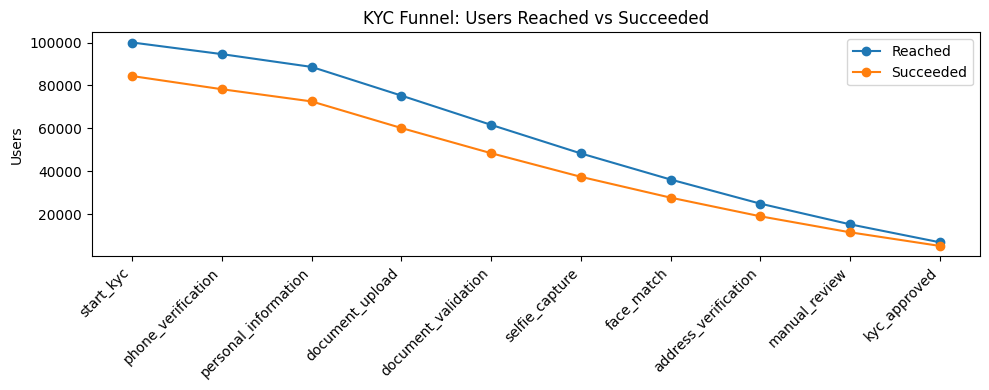

In [8]:
# Plot the funnel
plt.figure(figsize=(10, 4))
plt.plot(funnel["step"], funnel["users_reached"], marker="o", label="Reached")
plt.plot(funnel["step"], funnel["users_succeeded"], marker="o", label="Succeeded")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Users")
plt.title("KYC Funnel: Users Reached vs Succeeded")
plt.legend()
plt.tight_layout()
plt.show()


## **Exact step where users abandon**

In [9]:
# Because this dataset does not contain a full event timestamp for each KYC event,
# we use event_id as the event ordering proxy within each user.
kyc_sorted = kyc_enriched.sort_values(["user_id", "event_id"])

# The last event per user determines whether they finished or where they stopped
last_event = kyc_sorted.groupby("user_id").tail(1).copy()

# Approved users ended on the kyc_approved step
last_event["approved"] = (last_event["kyc_step"] == "kyc_approved").astype(int)

# For non-approved users, the last observed step is their drop step
last_event["drop_step"] = np.where(last_event["approved"] == 1, np.nan, last_event["kyc_step"])

drop_step_counts = (
    last_event[last_event["approved"] == 0]["drop_step"]
    .value_counts()
    .reindex(funnel_steps[:-1])
    .fillna(0)
    .astype(int)
)

drop_step_df = pd.DataFrame({
    "drop_step": drop_step_counts.index,
    "drop_users": drop_step_counts.values,
    "users_reached_step": [int(step_reached[s].sum()) for s in funnel_steps[:-1]],
})

# Conditional drop rate given that the user reached the step
drop_step_df["drop_rate_given_reached"] = (
    drop_step_df["drop_users"] / drop_step_df["users_reached_step"]
)

drop_step_df.sort_values("drop_users", ascending=False)


,drop_step,drop_users,users_reached_step,drop_rate_given_reached
2,personal_information,17179,88636,0.193815
3,document_upload,14513,75294,0.192751
4,document_validation,12362,61687,0.200399
5,selfie_capture,10231,48399,0.211389
0,start_kyc,9976,100000,0.099760
1,phone_verification,9083,94588,0.096027
6,face_match,8839,36258,0.243781
7,address_verification,7144,25032,0.285395
8,manual_review,5875,15415,0.381122


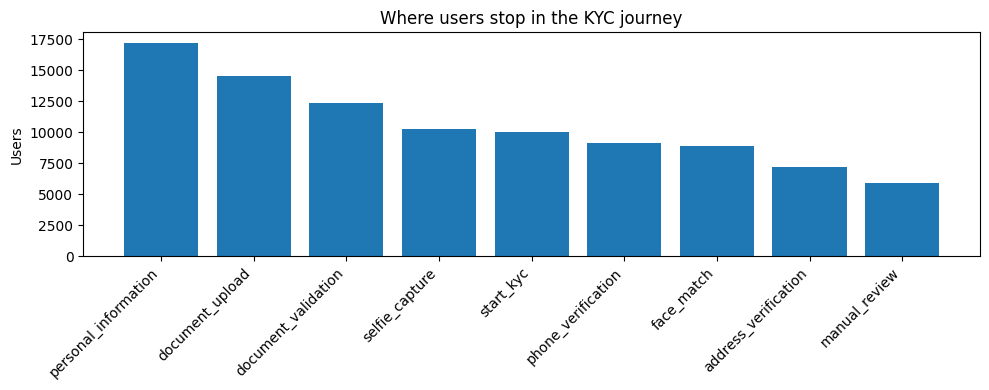

In [10]:
# Visualize where users stop
plt.figure(figsize=(10, 4))
tmp = drop_step_df.sort_values("drop_users", ascending=False)
plt.bar(tmp["drop_step"], tmp["drop_users"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Users")
plt.title("Where users stop in the KYC journey")
plt.tight_layout()
plt.show()


## **Status mix at each step**

In [11]:
step_status = (
    kyc_enriched.groupby(["kyc_step", "status"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(index=funnel_steps)
    .reset_index()
)

step_status["users_reached"] = step_status[["success", "fail", "abandon"]].sum(axis=1)

for col in ["success", "fail", "abandon"]:
    step_status[f"{col}_rate"] = step_status[col] / step_status["users_reached"]

step_status


status,kyc_step,abandon,fail,success,users_reached,success_rate,fail_rate,abandon_rate
0,start_kyc,14481,21460,84381,120322,0.701293,0.178355,0.120352
1,phone_verification,13217,19462,78254,110933,0.705417,0.175439,0.119144
2,personal_information,11739,17539,72582,101860,0.712566,0.172187,0.115246
3,document_upload,9338,13884,60208,83430,0.721659,0.166415,0.111926
4,document_validation,7177,10857,48500,66534,0.728951,0.163180,0.107870
5,selfie_capture,5469,8098,37516,51083,0.734413,0.158526,0.107061
6,face_match,3978,5899,27826,37703,0.738031,0.156460,0.105509
7,address_verification,2629,3939,19151,25719,0.744625,0.153155,0.102220
8,manual_review,1603,2353,11705,15661,0.747398,0.150246,0.102356
9,kyc_approved,701,1058,5367,7126,0.753157,0.148470,0.098372


## **Segment analysis**

In [12]:

# Create a few buckets to make the output easier to interpret
last_event["camera_bucket"] = pd.cut(
    last_event["camera_quality_score"],
    bins=[0, 3, 6, 10],
    labels=["low(1-3)", "mid(4-6)", "high(7-10)"],
    include_lowest=True
)

last_event["latency_bucket"] = pd.qcut(
    last_event["latency_ms"],
    q=4,
    labels=["low", "mid_low", "mid_high", "high"]
)

last_event["upload_bucket"] = pd.qcut(
    last_event["upload_speed_mbps"],
    q=4,
    labels=["slow", "mid_slow", "mid_fast", "fast"]
)

def drop_rate_by_segment(segment_col, target_steps):
    """
    For each segment, compute:
      users whose last drop step == X / users who reached step X
    """
    seg = last_event[["user_id", segment_col, "drop_step"]].drop_duplicates()
    out = {}

    for step in target_steps:
        reached_users = step_reached[step]
        reached_df = pd.DataFrame({
            "user_id": reached_users.index,
            "reached": reached_users.values
        })
        reached_df = reached_df[reached_df["reached"] == 1].merge(
            seg[["user_id", segment_col]],
            on="user_id",
            how="left"
        )

        denom = reached_df.groupby(segment_col, observed=False)["user_id"].nunique()
        num = seg[seg["drop_step"] == step].groupby(segment_col, observed=False)["user_id"].nunique()

        out[step] = (num / denom).replace([np.inf, np.nan], 0)

    return pd.DataFrame(out).fillna(0).reset_index()

# Example segment outputs
drop_rate_by_segment("network_type", ["document_upload", "document_validation", "selfie_capture", "face_match"])


,network_type,document_upload,document_validation,selfie_capture,face_match
0,3G,0.193459,0.205315,0.217256,0.246710
1,4G,0.192304,0.199750,0.213889,0.238847
2,5G,0.194823,0.200620,0.211550,0.256290
3,wifi,0.192507,0.199764,0.207366,0.244869


## **Approval rate by major segments**

In [13]:

user_approval = (
    last_event[["user_id", "approved"]]
    .merge(users[["user_id", "country", "acquisition_source"]], on="user_id", how="left")
    .merge(devices[["user_id", "device_type", "os", "camera_quality_score"]], on="user_id", how="left")
    .merge(network[["user_id", "network_type"]], on="user_id", how="left")
)

def approval_by(segment_col):
    out = user_approval.groupby(segment_col)["approved"].agg(users="count", approved="sum")
    out["approval_rate"] = out["approved"] / out["users"]
    return out.sort_values("approval_rate", ascending=False).reset_index()

approval_by("country")


,country,users,approved,approval_rate
0,South Africa,19928,987,0.049528
1,Kenya,20025,983,0.049089
2,India,20082,955,0.047555
3,UK,19904,939,0.047176
4,Nigeria,20061,934,0.046558


## **Key findings**

In [14]:
approved_users = int(last_event["approved"].sum())
total_users = int(last_event["user_id"].nunique())
approval_rate = approved_users / total_users

print(f"Approved users: {approved_users:,}")
print(f"Total users: {total_users:,}")
print(f"Overall approval rate: {approval_rate:.1%}")
print()
print("Highest raw drop-off steps:")
print(drop_step_df.sort_values("drop_users", ascending=False).head(5))


Approved users: 4,798
Total users: 100,000
Overall approval rate: 4.8%

Highest raw drop-off steps:
              drop_step  drop_users  users_reached_step  \
2  personal_information       17179               88636   
3       document_upload       14513               75294   
4   document_validation       12362               61687   
5        selfie_capture       10231               48399   
0             start_kyc        9976              100000   

   drop_rate_given_reached  
2                 0.193815  
3                 0.192751  
4                 0.200399  
5                 0.211389  
0                 0.099760  


## **Executive interpretation**

- The overall KYC approval rate is low relative to KYC starts.
- The largest raw user losses happen in the middle of the funnel: personal information, document upload, and document validation.
- The highest conditional loss rates appear in later steps such as manual review, address verification, and face match.
- The uploaded data is rich for device/network/time segmentation, but does not include experiment variant, KYC provider, support tickets, or post-approval transactions.
